In [1]:
import pandas as pd
df=pd.read_parquet("/content/traffic_weather_road.parquet")

In [2]:
df.sample(5)

,timestamp,sensor_id,speed,latitude_x,longitude_x,weather_time,temperature_2m,relative_humidity_2m,precipitation,rain,...,wind_gusts_10m,latitude_y,longitude_y,osmid,highway,length,lanes,maxspeed,oneway,distance_to_road
3001445,2012-05-18 22:40:00,717483,65.444444,34.11684,-118.33698,2012-05-18 22:00:00,16.0,67,0.0,0.0,...,10.8,34.11684,-118.33698,"[734604565, 862934679]",['motorway'],1142.266921,['5' '4'],['55 mph'],True,0.613695
5484613,2012-06-16 08:45:00,772178,63.285714,34.16903,-118.49885,2012-06-16 08:00:00,18.9,63,0.0,0.0,...,14.0,34.16903,-118.49885,"[55467113, 866581538, 55467114]",['motorway'],682.862572,['5'],['65 mph'],True,4.070324
1501320,2012-04-15 12:30:00,769359,51.222222,34.15660,-118.42216,2012-04-15 12:00:00,16.7,52,0.0,0.0,...,18.7,34.15660,-118.42216,"[55900242, 27287058, 55900237]",['motorway'],1022.758337,['5'],['65 mph'],True,0.501940
2194687,2012-04-02 03:35:00,717497,58.777778,34.15685,-118.41456,2012-04-02 03:00:00,6.6,78,0.0,0.0,...,30.6,34.15685,-118.41456,"[44335128, 44335129, 862427534]",['motorway'],607.157516,['5'],['65 mph'],True,1.565605
4885086,2012-03-08 09:30:00,717469,56.333333,34.09710,-118.31366,2012-03-08 09:00:00,9.7,18,0.0,0.0,...,32.4,34.09710,-118.31366,148238623,['motorway'],283.365344,['4'],['55 mph'],True,3.808115


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6565709 entries, 0 to 6565708
Data columns (total 23 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   sensor_id             object        
 2   speed                 float64       
 3   latitude_x            float64       
 4   longitude_x           float64       
 5   weather_time          datetime64[ns]
 6   temperature_2m        float64       
 7   relative_humidity_2m  int64         
 8   precipitation         float64       
 9   rain                  float64       
 10  weather_code          int64         
 11  cloud_cover           int64         
 12  wind_speed_10m        float64       
 13  wind_gusts_10m        float64       
 14  latitude_y            float64       
 15  longitude_y           float64       
 16  osmid                 object        
 17  highway               object        
 18  length                float64       
 19  

In [4]:
df = df.rename(columns={
    "latitude_x": "latitude",
    "longitude_x": "longitude"
})

df = df.drop(columns=["latitude_y", "longitude_y"], errors="ignore")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6565709 entries, 0 to 6565708
Data columns (total 21 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   sensor_id             object        
 2   speed                 float64       
 3   latitude              float64       
 4   longitude             float64       
 5   weather_time          datetime64[ns]
 6   temperature_2m        float64       
 7   relative_humidity_2m  int64         
 8   precipitation         float64       
 9   rain                  float64       
 10  weather_code          int64         
 11  cloud_cover           int64         
 12  wind_speed_10m        float64       
 13  wind_gusts_10m        float64       
 14  osmid                 object        
 15  highway               object        
 16  length                float64       
 17  lanes                 object        
 18  maxspeed              object        
 19  

In [5]:
import numpy as np
import pandas as pd
import re

def clean_lanes(x):
    if pd.isna(x) or x == "nan":
        return np.nan
    nums = re.findall(r"\d+", str(x))
    return float(nums[0]) if nums else np.nan

def clean_maxspeed(x):
    if pd.isna(x) or x == "nan":
        return np.nan
    nums = re.findall(r"\d+", str(x))
    return float(nums[0]) if nums else np.nan

df["lanes"] = df["lanes"].apply(clean_lanes)
df["maxspeed"] = df["maxspeed"].apply(clean_maxspeed)

df["highway"] = df["highway"].astype(str)
df["oneway"] = df["oneway"].astype(int)

In [6]:
df["lanes"] = df.groupby("highway")["lanes"].transform(
    lambda x: x.fillna(x.median())
)

df["maxspeed"] = df.groupby("highway")["maxspeed"].transform(
    lambda x: x.fillna(x.median())
)

df["lanes"] = df["lanes"].fillna(df["lanes"].median())
df["maxspeed"] = df["maxspeed"].fillna(df["maxspeed"].median())

print(df[["lanes", "maxspeed"]].isna().sum())

lanes       0
maxspeed    0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6565709 entries, 0 to 6565708
Data columns (total 21 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   sensor_id             object        
 2   speed                 float64       
 3   latitude              float64       
 4   longitude             float64       
 5   weather_time          datetime64[ns]
 6   temperature_2m        float64       
 7   relative_humidity_2m  int64         
 8   precipitation         float64       
 9   rain                  float64       
 10  weather_code          int64         
 11  cloud_cover           int64         
 12  wind_speed_10m        float64       
 13  wind_gusts_10m        float64       
 14  osmid                 object        
 15  highway               object        
 16  length                float64       
 17  lanes                 float64       
 18  maxspeed              float64       
 19  

In [8]:
df.isnull().sum()

,0
timestamp,0
sensor_id,0
speed,0
latitude,0
longitude,0
weather_time,0
temperature_2m,0
relative_humidity_2m,0
precipitation,0
rain,0


In [9]:
df.sample(5)

,timestamp,sensor_id,speed,latitude,longitude,weather_time,temperature_2m,relative_humidity_2m,precipitation,rain,...,cloud_cover,wind_speed_10m,wind_gusts_10m,osmid,highway,length,lanes,maxspeed,oneway,distance_to_road
4140585,2012-05-14 18:00:00,764781,33.750000,34.16037,-118.47012,2012-05-14 18:00:00,24.4,29,0.0,0.0,...,0,9.9,34.2,681293322,['motorway'],375.898614,4.0,65.0,1,1.836191
1376725,2012-04-23 10:20:00,760024,57.625000,34.15930,-118.46483,2012-04-23 10:00:00,14.3,77,0.0,0.0,...,17,6.6,19.8,"[27827549, 24813109]",['motorway'],475.669218,6.0,65.0,1,4.840601
4420139,2012-04-19 14:00:00,716958,58.625000,34.11167,-118.26501,2012-04-19 14:00:00,26.8,39,0.0,0.0,...,47,3.4,30.6,864130999,['motorway'],693.803234,5.0,65.0,1,6.522359
1516502,2012-06-08 22:30:00,769359,65.555556,34.15660,-118.42216,2012-06-08 22:00:00,17.5,62,0.0,0.0,...,0,2.5,10.1,"[55900242, 27287058, 55900237]",['motorway'],1022.758337,5.0,65.0,1,0.501940
2937861,2012-05-20 03:05:00,767585,68.875000,34.16556,-118.22432,2012-05-20 03:00:00,15.0,80,0.0,0.0,...,0,5.4,8.6,860695122,['motorway'],893.208114,5.0,65.0,1,5.284022


In [10]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["is_morning_peak"] = df["hour"].between(7, 10).astype(int)
df["is_evening_peak"] = df["hour"].between(16, 19).astype(int)
df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)

In [11]:
df = df.sort_values(["sensor_id", "timestamp"]).reset_index(drop=True)

for lag in [1, 2, 3, 6, 12]:
    df[f"speed_lag_{lag}"] = df.groupby("sensor_id")["speed"].shift(lag)

In [12]:
df["rolling_mean_3"] = df.groupby("sensor_id")["speed"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

df["rolling_mean_6"] = df.groupby("sensor_id")["speed"].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

df["rolling_std_6"] = df.groupby("sensor_id")["speed"].transform(
    lambda x: x.shift(1).rolling(6).std()
)

df["speed_change_1"] = df["speed"] - df["speed_lag_1"]
df["speed_change_3"] = df["speed"] - df["speed_lag_3"]

In [13]:
df.sample(5)

,timestamp,sensor_id,speed,latitude,longitude,weather_time,temperature_2m,relative_humidity_2m,precipitation,rain,...,speed_lag_1,speed_lag_2,speed_lag_3,speed_lag_6,speed_lag_12,rolling_mean_3,rolling_mean_6,rolling_std_6,speed_change_1,speed_change_3
1997063,2012-03-07 13:45:00,717580,66.111111,34.15620,-118.26359,2012-03-07 13:00:00,14.8,9,0.0,0.0,...,66.333333,66.625000,65.500000,66.500,66.375,66.152778,66.164352,0.436245,-0.222222,0.611111
2858905,2012-04-16 13:40:00,718379,62.000000,34.14224,-118.27812,2012-04-16 13:00:00,23.3,36,0.0,0.0,...,62.750000,59.222222,60.500000,51.875,59.875,60.824074,59.166667,3.770448,-0.750000,1.500000
542984,2012-04-09 04:00:00,716968,49.666667,34.16588,-118.29809,2012-04-09 04:00:00,8.8,53,0.0,0.0,...,58.000000,62.625000,65.285714,65.625,66.625,61.970238,62.931878,2.745011,-8.333333,-15.619048
4439201,2012-03-04 23:25:00,767573,67.875000,34.12964,-118.22901,2012-03-04 23:00:00,14.4,27,0.0,0.0,...,68.750000,68.857143,67.777778,69.125,69.375,68.461640,67.527116,2.854896,-0.875000,0.097222
342393,2012-06-10 20:10:00,716949,65.888889,34.08406,-118.22974,2012-06-10 20:00:00,19.9,57,0.0,0.0,...,66.428571,66.333333,66.000000,66.375,67.000,66.253968,66.393188,0.333830,-0.539683,-0.111111


In [14]:
base = df[["sensor_id", "timestamp", "speed"]].copy()

for minutes in [5, 15, 30]:
    target = base.copy()
    target["timestamp"] = target["timestamp"] - pd.Timedelta(minutes=minutes)
    target = target.rename(columns={"speed": f"target_speed_{minutes}min"})

    df = df.merge(
        target,
        on=["sensor_id", "timestamp"],
        how="left"
    )

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6565709 entries, 0 to 6565708
Data columns (total 41 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   sensor_id             object        
 2   speed                 float64       
 3   latitude              float64       
 4   longitude             float64       
 5   weather_time          datetime64[ns]
 6   temperature_2m        float64       
 7   relative_humidity_2m  int64         
 8   precipitation         float64       
 9   rain                  float64       
 10  weather_code          int64         
 11  cloud_cover           int64         
 12  wind_speed_10m        float64       
 13  wind_gusts_10m        float64       
 14  osmid                 object        
 15  highway               object        
 16  length                float64       
 17  lanes                 float64       
 18  maxspeed              float64       
 19  

In [16]:
model_df = df.dropna().reset_index(drop=True)

print("Final model dataset shape:", model_df.shape)
model_df.head()

Final model dataset shape: (6468231, 41)


,timestamp,sensor_id,speed,latitude,longitude,weather_time,temperature_2m,relative_humidity_2m,precipitation,rain,...,speed_lag_6,speed_lag_12,rolling_mean_3,rolling_mean_6,rolling_std_6,speed_change_1,speed_change_3,target_speed_5min,target_speed_15min,target_speed_30min
0,2012-03-01 01:10:00,716328,66.750000,34.06664,-118.25397,2012-03-01 01:00:00,6.6,94,0.0,0.0,...,55.875000,66.875000,66.087963,64.444444,4.355986,-1.138889,2.375000,63.000000,65.555556,63.000000
1,2012-03-01 01:15:00,716328,63.000000,34.06664,-118.25397,2012-03-01 01:00:00,6.6,94,0.0,0.0,...,65.750000,67.444444,66.879630,66.256944,1.186789,-3.750000,-3.000000,65.000000,67.444444,58.000000
2,2012-03-01 01:20:00,716328,65.000000,34.06664,-118.25397,2012-03-01 01:00:00,6.6,94,0.0,0.0,...,66.777778,65.000000,65.879630,65.798611,1.796253,2.000000,-2.888889,65.555556,62.750000,66.777778
3,2012-03-01 01:25:00,716328,65.555556,34.06664,-118.25397,2012-03-01 01:00:00,6.6,94,0.0,0.0,...,64.375000,65.666667,64.916667,65.502315,1.748421,0.555556,-1.194444,67.444444,63.000000,67.250000
4,2012-03-01 01:30:00,716328,67.444444,34.06664,-118.25397,2012-03-01 01:00:00,6.6,94,0.0,0.0,...,66.000000,65.250000,64.518519,65.699074,1.660397,1.888889,4.444444,62.750000,58.000000,66.333333


In [17]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468231 entries, 0 to 6468230
Data columns (total 41 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   sensor_id             object        
 2   speed                 float64       
 3   latitude              float64       
 4   longitude             float64       
 5   weather_time          datetime64[ns]
 6   temperature_2m        float64       
 7   relative_humidity_2m  int64         
 8   precipitation         float64       
 9   rain                  float64       
 10  weather_code          int64         
 11  cloud_cover           int64         
 12  wind_speed_10m        float64       
 13  wind_gusts_10m        float64       
 14  osmid                 object        
 15  highway               object        
 16  length                float64       
 17  lanes                 float64       
 18  maxspeed              float64       
 19  

## For target_speed_5min



In [18]:
drop_cols = [
    "timestamp",
    "weather_time",
    "sensor_id",
    "osmid",
    "target_speed_5min",
    "target_speed_15min",
    "target_speed_30min"
]

X=model_df.drop(columns=drop_cols)
y=model_df['target_speed_5min']

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468231 entries, 0 to 6468230
Data columns (total 34 columns):
 #   Column                Dtype  
---  ------                -----  
 0   speed                 float64
 1   latitude              float64
 2   longitude             float64
 3   temperature_2m        float64
 4   relative_humidity_2m  int64  
 5   precipitation         float64
 6   rain                  float64
 7   weather_code          int64  
 8   cloud_cover           int64  
 9   wind_speed_10m        float64
 10  wind_gusts_10m        float64
 11  highway               object 
 12  length                float64
 13  lanes                 float64
 14  maxspeed              float64
 15  oneway                int64  
 16  distance_to_road      float64
 17  hour                  int32  
 18  day_of_week           int32  
 19  month                 int32  
 20  is_weekend            int64  
 21  is_morning_peak       int64  
 22  is_evening_peak       int64  
 23  is_nigh

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["highway"] = le.fit_transform(X["highway"].astype(str))

In [23]:
import pickle
with open("highway_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [21]:
X['highway'].unique()

array([0, 2, 1])

In [22]:
print(X.isna().sum().sum())
print(y.isna().sum())

0
0


In [23]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(5174584, 34) (1293647, 34)


In [24]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = baseline_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 2.639
RMSE: 4.237
R²  : 0.887


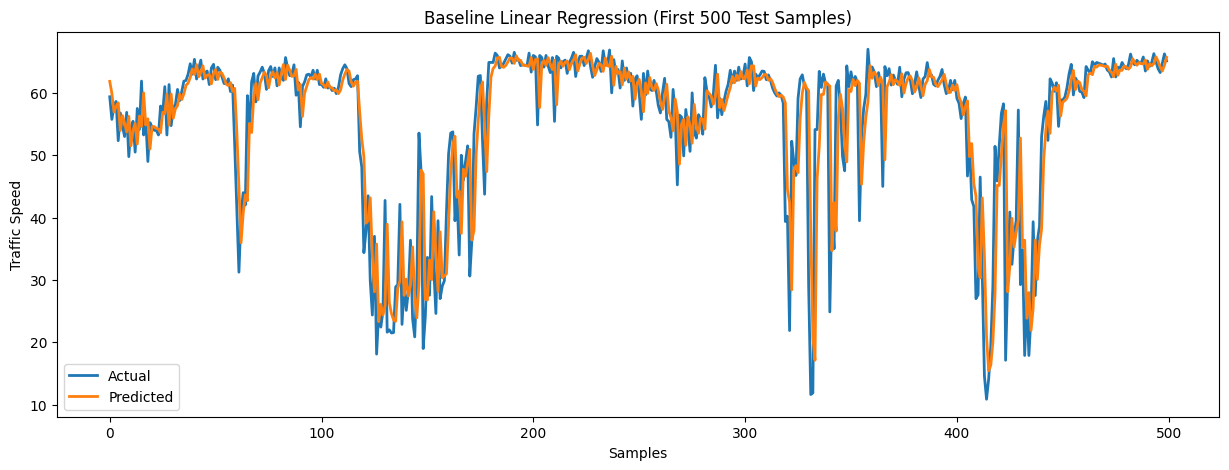

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_test.iloc[:500].values, label="Actual", linewidth=2)
plt.plot(y_pred[:500], label="Predicted", linewidth=2)

plt.xlabel("Samples")
plt.ylabel("Traffic Speed")
plt.title("Baseline Linear Regression (First 500 Test Samples)")
plt.legend()

plt.show()

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"LightGBM MAE : {mae:.3f} mph")
print(f"LightGBM RMSE: {rmse:.3f} mph")
print(f"LightGBM R²  : {r2:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.113463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4317
[LightGBM] [Info] Number of data points in the train set: 5174584, number of used features: 34
[LightGBM] [Info] Start training from score 58.724806
LightGBM MAE : 2.580 mph
LightGBM RMSE: 4.101 mph
LightGBM R²  : 0.894


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"LightGBM MAE : {mae:.3f} mph")
print(f"LightGBM RMSE: {rmse:.3f} mph")
print(f"LightGBM R²  : {r2:.3f}")

LightGBM MAE : 2.701 mph
LightGBM RMSE: 4.214 mph
LightGBM R²  : 0.888


In [25]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"CatBoost MAE : {mae:.3f} mph")
print(f"CatBoost RMSE: {rmse:.3f} mph")
print(f"CatBoost R²  : {r2:.3f}")

0:	learn: 12.5360144	total: 1.38s	remaining: 11m 30s
100:	learn: 4.0019245	total: 2m 28s	remaining: 9m 46s
200:	learn: 3.9521788	total: 4m 43s	remaining: 7m 2s
300:	learn: 3.9283934	total: 7m 9s	remaining: 4m 44s
400:	learn: 3.9108966	total: 9m 25s	remaining: 2m 19s
499:	learn: 3.8969937	total: 11m 42s	remaining: 0us


NameError: name 'mean_absolute_error' is not defined

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"CatBoost MAE : {mae:.3f} mph")
print(f"CatBoost RMSE: {rmse:.3f} mph")
print(f"CatBoost R²  : {r2:.3f}")

CatBoost MAE : 2.541 mph
CatBoost RMSE: 4.070 mph
CatBoost R²  : 0.896


In [28]:
import pickle

with open('catboost.pkl', 'wb') as f:
    pickle.dump(cat, f)

## For target_speed_15min


In [29]:
drop_cols = [
    "timestamp",
    "weather_time",
    "sensor_id",
    "osmid",
    "target_speed_5min",
    "target_speed_15min",
    "target_speed_30min"
]

X=model_df.drop(columns=drop_cols)
y=model_df['target_speed_15min']

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["highway"] = le.fit_transform(X["highway"].astype(str))

In [31]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(5174584, 34) (1293647, 34)


In [32]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"LightGBM MAE : {mae:.3f} mph")
print(f"LightGBM RMSE: {rmse:.3f} mph")
print(f"LightGBM R²  : {r2:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.127154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4317
[LightGBM] [Info] Number of data points in the train set: 5174584, number of used features: 34
[LightGBM] [Info] Start training from score 58.724386
LightGBM MAE : 3.422 mph
LightGBM RMSE: 5.618 mph
LightGBM R²  : 0.802


In [33]:
import pickle

with open('lgbm_15min.pkl', 'wb') as f:
    pickle.dump(model, f)

In [34]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Catboost MAE : {mae:.3f} mph")
print(f"Catboost RMSE: {rmse:.3f} mph")
print(f"Catboost R²  : {r2:.3f}")

0:	learn: 12.6047755	total: 1.42s	remaining: 11m 47s
100:	learn: 5.6454408	total: 2m 24s	remaining: 9m 29s
200:	learn: 5.5571959	total: 4m 45s	remaining: 7m 4s
300:	learn: 5.5117907	total: 7m 10s	remaining: 4m 44s
400:	learn: 5.4761679	total: 9m 30s	remaining: 2m 20s
499:	learn: 5.4491525	total: 11m 55s	remaining: 0us
Catboost MAE : 3.345 mph
Catboost RMSE: 5.541 mph
Catboost R²  : 0.807


In [35]:
import pickle

with open('catboost_15min.pkl', 'wb') as f:
    pickle.dump(cat, f)

## For target_speed_30min



In [19]:
drop_cols = [
    "timestamp",
    "weather_time",
    "sensor_id",
    "osmid",
    "target_speed_5min",
    "target_speed_15min",
    "target_speed_30min"
]

X=model_df.drop(columns=drop_cols)
y=model_df['target_speed_30min']

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["highway"] = le.fit_transform(X["highway"].astype(str))

In [21]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(5174584, 34) (1293647, 34)


In [22]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"LightGBM MAE : {mae:.3f} mph")
print(f"LightGBM RMSE: {rmse:.3f} mph")
print(f"LightGBM R²  : {r2:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.848505 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4317
[LightGBM] [Info] Number of data points in the train set: 5174584, number of used features: 34
[LightGBM] [Info] Start training from score 58.724458
LightGBM MAE : 4.307 mph
LightGBM RMSE: 6.947 mph
LightGBM R²  : 0.697


In [23]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Catboost MAE : {mae:.3f} mph")
print(f"Catboost RMSE: {rmse:.3f} mph")
print(f"Catboost R²  : {r2:.3f}")

0:	learn: 12.6778395	total: 1.48s	remaining: 12m 17s
100:	learn: 6.9122434	total: 2m 27s	remaining: 9m 44s
200:	learn: 6.7637807	total: 4m 45s	remaining: 7m 5s
300:	learn: 6.6835511	total: 7m 8s	remaining: 4m 43s
400:	learn: 6.6226469	total: 9m 43s	remaining: 2m 23s
499:	learn: 6.5694160	total: 12m 2s	remaining: 0us
Catboost MAE : 4.233 mph
Catboost RMSE: 6.877 mph
Catboost R²  : 0.703


In [24]:
import pickle

with open('catboost_30min.pkl', 'wb') as f:
    pickle.dump(cat, f)